In [38]:
import os
import chardet
import pandas as pd
from sklearn.model_selection import train_test_split

random_state = 7
no_of_active_features = 15

def get_encoding(file_path):
    with open(file_path, "rb") as f:
        data = f.read(10000)
    return chardet.detect(data).get("encoding")


def read_files(file_path: str):
    if file_path == None:
        print("Enter filepath")
        return

    false_feature_file = "rq2_vosoughi_False_features.csv"
    true_feature_file = "rq2_vosoughi_True_features.csv"
    true_file = os.path.join(file_path + os.path.sep + true_feature_file)
    false_file = os.path.join(file_path + os.path.sep + false_feature_file)

    vosoughi_false_df = pd.read_csv(
        false_file, index_col=0, sep=",", encoding=get_encoding(false_file)
    )
    vosoughi_true_df = pd.read_csv(
        true_file, index_col=0, sep=",", encoding=get_encoding(true_file)
    )
    vosoughi_df = pd.concat([vosoughi_false_df, vosoughi_true_df])
    return vosoughi_df


def filter_and_split_df(df: pd.DataFrame):

    test_size = 0.15

    filtered_df = df[(df.characteristic_distance != -99999) & (df.depth != 0)]
    filtered_df = filtered_df.drop(columns=["avg_cluster_coef"], axis=1)
    filtered_df = filtered_df.drop(["weakly_cc"], axis=1)
    total_features = no_of_active_features - 2

    X = filtered_df.iloc[:, 3:total_features]
    Y = filtered_df.iloc[:, total_features]
    X_train_val_full, X_test_full, y_train_val_full, y_test_full = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    print(X_train_val_full.shape, X_test_full.shape, y_train_val_full.shape, y_test_full.shape)
    
    return X_train_val_full, X_test_full, y_train_val_full, y_test_full

x_train_val_full, x_test_full, y_train_val_full, y_test_full = filter_and_split_df(read_files('../'))

(32305, 10) (5702, 10) (32305,) (5702,)


In [20]:
# import pickle 

# with open("./x_train_val_full.pickle", "wb") as file:
#     pickle.dump(x_train_val_full, file)

# with open("./y_train_val_full.pickle", "wb") as file:
#     pickle.dump(y_train_val_full, file)

# with open("./x_test_full.pickle", "wb") as file:
#     pickle.dump(x_test_full, file)

# with open("./y_test_full.pickle", "wb") as file:
#     pickle.dump(y_test_full, file)

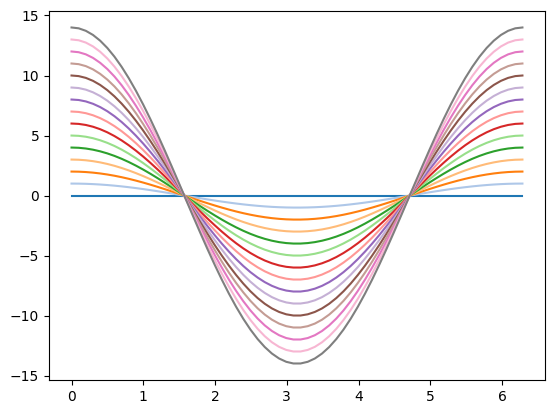

In [24]:
import numpy as np
import matplotlib.pylab as plt
import matplotlib.colors as cm

x = np.linspace(0, 2*np.pi, 64)
y = np.cos(x) 

plt.figure()

n = 15
color = iter([cm.to_hex(plt.cm.tab20(i)) for i in range(n)])

for i in range(n):
    plt.plot(x, i*y, color=next(color))

In [37]:
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE
from copy import copy
from sklearn.preprocessing import StandardScaler

total_features = 13

x_train_file = "./rq2_x_train_df.csv"

train_file = os.path.join(x_train_file)

train_df = pd.read_csv(
    train_file, index_col=0, sep=","
)

X_train_val = train_df.iloc[:, 3:total_features]
y_train_val = train_df.iloc[:, total_features]

normalized_df = copy(X_train_val)
cd_first_quantile = np.quantile(normalized_df["size"], 0.25)
cd_third_quantile = np.quantile(normalized_df["size"], 0.75)
normalized_df["depth"] = np.log(normalized_df["depth"])
normalized_df["size"] = np.log(normalized_df["size"])
normalized_df["max_breadth"] = np.log(normalized_df["max_breadth"])
normalized_df["strongly_cc"] = np.log(normalized_df["strongly_cc"])
normalized_df["characteristic_distance"] = np.log(
    normalized_df["characteristic_distance"]
    + cd_first_quantile**2 / cd_third_quantile
)

In [1]:
import pickle
import pandas as pd

def read_pickled_input_files(file_path: str):
    
    X_train_val = None
    y_train_val = None
    X_test = None
    y_test = None

    # wandb.init(project=wandb_project)

    with open(file_path + "/x_train_val_full.pickle", "rb") as file:
        X_train_val = pickle.load(file)
        # joblib.dump(X_train_val, "x_train_val.joblib")
        # x_train_val_artifact = wandb.Artifact("x_train_val.joblib", type="dataset")
        # x_train_val_artifact.add_file("x_train_val.joblib")
        # wandb.log_artifact(x_train_val_artifact)

    with open(file_path + "/y_train_val_full.pickle", "rb") as file:
        y_train_val = pickle.load(file)
        # joblib.dump(y_train_val, "y_train_val.joblib")
        # y_train_val_artifact = wandb.Artifact("y_train_val.joblib", type="dataset")
        # y_train_val_artifact.add_file("y_train_val.joblib")
        # wandb.log_artifact(y_train_val_artifact)

    with open(file_path + "/x_test_full.pickle", "rb") as file:
        X_test = pickle.load(file)
        # joblib.dump(X_test, "x_test.joblib")
        # x_test_artifact = wandb.Artifact("x_test.joblib", type="dataset")
        # x_test_artifact.add_file("x_test.joblib")
        # wandb.log_artifact(x_test_artifact)

    with open(file_path + "/y_test_full.pickle", "rb") as file:
        y_test = pickle.load(file)
        # joblib.dump(y_test, "y_test.joblib")
        # y_test_artifact = wandb.Artifact("y_test.joblib", type="dataset")
        # y_test_artifact.add_file("y_test.joblib")
        # wandb.log_artifact(y_test_artifact)

    # wandb.finish()
    
    return X_train_val, X_test, y_train_val, y_test

X_train_val, X_test, y_train_val, y_test = read_pickled_input_files("../image")

print(f"shapes of input: {X_train_val.shape}, {X_test.shape}, {y_train_val.shape}, {y_test.shape}")

shapes of input: (32305, 10), (5702, 10), (32305,), (5702,)


In [2]:
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    average_precision_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)

def precision_0(y, y_pred):
    returned_arr = precision_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[0]

def precision_1(y, y_pred):
    returned_arr = precision_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[1]

def recall_0(y, y_pred):
    returned_arr = recall_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[0]

def recall_1(y, y_pred):
    returned_arr = recall_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[1]

scorers_for_gridcv = {
    "accuracy_score": make_scorer(accuracy_score),
    "precision_0": make_scorer(precision_0, greater_is_better=True),
    "precision_1": make_scorer(precision_1, greater_is_better=True),
    "recall_0": make_scorer(recall_0, greater_is_better=True),
    "recall_1": make_scorer(recall_1, greater_is_better=True),
    "fbeta_score": make_scorer(fbeta_score, beta=0.5),
    "balanced_accuracy_score": make_scorer(balanced_accuracy_score),
    "average_precision_score": make_scorer(average_precision_score),
    "roc_auc": make_scorer(roc_auc_score)
}


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
total_cv = 5
random_state = 7
no_of_active_features = 15
optimization_metric = "average_precision_score"

# logit_grid = {
#     "penalty": ["l2", "l1"],
# }
logit_grid = {
    "penalty": ["l1", "l2", "elasticnet"],
    "dual": [True, False],
    "C": [_ for _ in range(1, 10, 1)],
    "fit_intercept": [True, False],
    "max_iter": [500],
    "solver": ["lbfgs", "newton-cg", "newton-cholesky", "sag", "saga"],
    "n_jobs": [-1],
}
logit_model = LogisticRegression()

clf = GridSearchCV(
    estimator=logit_model,
    cv=total_cv,
    refit=optimization_metric,
    param_grid=logit_grid,
    scoring=scorers_for_gridcv,
    verbose=0,
    n_jobs=-1,
)

logit_result = clf.fit(X_train_val, y_train_val)

# if logit_result != None:
#     process_gridcv_results(logit_result.cv_results_, "logit")


KeyboardInterrupt: 

{'mean_fit_time': array([0.81570082, 0.01047173]), 'std_fit_time': array([0.03055575, 0.00375579]), 'mean_score_time': array([0.12851377, 0.        ]), 'std_score_time': array([0.00987977, 0.        ]), 'param_penalty': masked_array(data=['l2', 'l1'],
             mask=[False, False],
       fill_value='?',
            dtype=object), 'params': [{'penalty': 'l2'}, {'penalty': 'l1'}], 'split0_test_accuracy_score': array([0.83826033,        nan]), 'split1_test_accuracy_score': array([0.83810556,        nan]), 'split2_test_accuracy_score': array([0.83810556,        nan]), 'split3_test_accuracy_score': array([0.83810556,        nan]), 'split4_test_accuracy_score': array([0.83810556,        nan]), 'mean_test_accuracy_score': array([0.83813651,        nan]), 'std_test_accuracy_score': array([6.19099211e-05,            nan]), 'rank_test_accuracy_score': array([1, 2]), 'split0_test_precision_0': array([0.83826033,        nan]), 'split1_test_precision_0': array([0.83810556,        nan]), 'split2

In [9]:
temp = logit_result.cv_results_
d = pd.DataFrame.from_dict(temp)
d.sort_values(by="rank_test_average_precision_score", ascending=True)['mean_test_accuracy_score'].iloc[0]

0.838136511375948

In [13]:
cv_result = logit_result.cv_results_
cv_result_df = pd.DataFrame.from_dict(cv_result)
cv_result_df.sort_values(by="rank_test_average_precision_score", ascending=True, inplace=True)
mean_test_accuracy_score = round(cv_result_df['mean_test_accuracy_score'].iloc[0], 2)
mean_test_precision_0 = round(cv_result_df['mean_test_precision_0'].iloc[0], 2)
mean_test_precision_1 = round(cv_result_df['mean_test_precision_1'].iloc[0], 2)
mean_test_recall_0 = round(cv_result_df['mean_test_recall_0'].iloc[0], 2)
mean_test_recall_1 = round(cv_result_df['mean_test_recall_1'].iloc[0], 2)
mean_test_fbeta_score = round(cv_result_df['mean_test_fbeta_score'].iloc[0], 2)
mean_test_balanced_accuracy_score = round(cv_result_df['mean_test_balanced_accuracy_score'].iloc[0], 2)
mean_test_average_precision_score = round(cv_result_df['mean_test_average_precision_score'].iloc[0], 2)
mean_test_roc_auc = round(cv_result_df['mean_test_roc_auc'].iloc[0], 2)
print(mean_test_accuracy_score, mean_test_precision_0, mean_test_precision_1, mean_test_recall_0, mean_test_recall_1, mean_test_fbeta_score, mean_test_balanced_accuracy_score, mean_test_average_precision_score, mean_test_roc_auc)

0.84 0.84 0.0 1.0 0.0 0.0 0.5 0.16 0.5


In [14]:
import wandb
import os 

os.environ["WANDB_API_KEY"] = "b21f4406f3966154b12e98de3bef934216952a54"
os.environ["WANDB_ENTITY"] = "istiyaksiddiquee"
os.environ["WANDB__SERVICE_WAIT"] = "300"


wandb.init(project='RQ2RUN7', group='logit', job_type='epoch_5')
wandb.log({
    "test_accuracy": 5.0, 
})

wandb.finish()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: istiyaksiddiquee. Use `wandb login --relogin` to force relogin


test_accuracy,▁
test_accuracy,5.0


In [25]:
logit_result.best_score_
logit_result.best_estimator_

0.16186348862405203

In [14]:
import os
import wandb

os.environ["WANDB_API_KEY"] = "b21f4406f3966154b12e98de3bef934216952a54"
os.environ["WANDB_ENTITY"] = "istiyaksiddiquee"

# run = wandb.init(project="test-1", job_type="demo_run_2")

run = wandb.init(project="RQ2RUN3")

# artifact = run.use_artifact("RQ2RUN6/Most-Freq-Dummy-Cls:latest")
# model_dir = artifact.download()

artifact = run.use_artifact("RQ2RUN3/XGB-Model:latest")
model_dir = artifact.download()

# artifact = run.use_artifact("RQ2RUN6/Decision-Tree-Model:latest")
# model_dir = artifact.download()

# artifact = run.use_artifact("RQ2RUN5/XGB-Model:latest")
# model_dir = artifact.download()

# artifact = run.use_artifact("RQ2RUN5/LGB-Model:latest")
# model_dir = artifact.download()

wandb:   1 of 1 files downloaded.  


In [2]:
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    average_precision_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from copy import copy

def get_all_scores(y_real, y_pred, y_scores):
    accuracy = accuracy_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred, average=None)
    recall = recall_score(y_real, y_pred, average=None)
    balanced_accuracy = balanced_accuracy_score(y_real, y_pred)
    fbeta = fbeta_score(y_real, y_pred, beta=0.5)
    avg_precision = average_precision_score(y_real, y_scores)
    roc_auc = roc_auc_score(y_real, y_scores)

    return accuracy, precision, recall, balanced_accuracy, fbeta, avg_precision, roc_auc

def flip_true_false(y):
    copy_y = copy(y)
    flipped_y = [0 if item == 1 else 1 for item in copy_y]
    return flipped_y

def test_model(model):
    y_pred = model.predict(X_test.values)
    y_pred_proba = model.predict_proba(X_test.values)
    
    return get_all_scores(y_test, y_pred, y_pred_proba[:, 1])

    # flipped_y = flip_true_false(y_pred)
    # print(get_all_scores(y_test, flipped_y, y_pred_proba[:, 0]))

In [5]:
# accuracy, precision, recall, balanced_accuracy, fbeta, avg_precision, roc_auc
import joblib
model1 = joblib.load('./artifacts/RQ2RUN3/xgb.joblib')
a = test_model(model1)
print(a)
temp1 = model1.predict_proba(X_test.values)


(0.16134689582602596, array([0.       , 0.1613469]), array([0., 1.]), 0.5, 0.193863789615644, 0.16134689582602596, 0.5)


C:\Users\istiyak\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [6]:
# accuracy, precision, recall, balanced_accuracy, fbeta, avg_precision, roc_auc
import joblib
model2 = joblib.load('./artifacts/RQ2RUN6/xgb.joblib')
b = test_model(model2)
print(b)
temp2 = model2.predict_proba(X_test.values)

(0.16134689582602596, array([0.       , 0.1613469]), array([0., 1.]), 0.5, 0.193863789615644, 0.16134689582602596, 0.5)


C:\Users\istiyak\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [8]:
import numpy as np
np.sum(temp1-temp2)


0.0

In [11]:
# accuracy, precision, recall, balanced_accuracy, fbeta, avg_precision, roc_auc

model = joblib.load('./RQ2RUN6-artifacts/Decision-Tree-Model-v0/dt.joblib')
a = test_model(model)
print(a)

(0.8386531041739741, array([0.8386531, 0.       ]), array([1., 0.]), 0.5, 0.0, 0.16134689582602596, 0.5)


In [13]:
model = joblib.load('./RQ2RUN6-artifacts/Most-Freq-Dummy-Cls-v0/most_freq_dummy_cls.joblib')
a = test_model(model)
print(a)

(0.8386531041739741, array([0.8386531, 0.       ]), array([1., 0.]), 0.5, 0.0, 0.16134689582602596, 0.5)


In [18]:
model = joblib.load('./RQ2RUN5-artifacts/RF-Model-v0/rf.joblib')
test_model(model)

(0.658716239915819, array([0.86044738, 0.20984163]), array([0.70786282, 0.40326087]), 0.5555618442347208, 0.23210710710710714, 0.18831047481578833, 0.5456039859618497)


In [23]:
model = joblib.load('./RQ2RUN5-artifacts/XGB-Model-v0/xgb.joblib')
test_model(model)

(0.16134689582602596, array([0.       , 0.1613469]), array([0., 1.]), 0.5, 0.193863789615644, 0.16134689582602596, 0.5)


In [24]:
model = joblib.load('./RQ2RUN5-artifacts/LGB-Model-v0/lgb.joblib')
test_model(model)

(0.8276043493511048, array([0.83697002, 0.01538462]), array([0.98661648, 0.00108696]), 0.4938517174913171, 0.004237288135593221, 0.16118824117337224, 0.49385171749131707)


In [20]:
model

LogisticRegression(C=5, max_iter=500, n_jobs=-1, solver='newton-cholesky')

In [5]:
import shap
explainer = shap.Explainer(model.predict, X_test)
# Calculates the SHAP values - It takes some time
shap_values = explainer(X_test)

ExactExplainer explainer: 5703it [00:33, 137.95it/s]                          


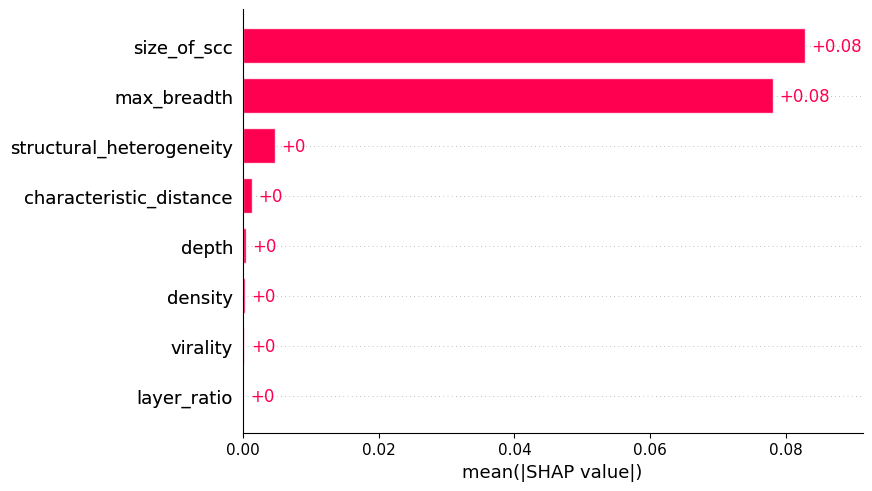

In [6]:
shap.plots.bar(shap_values)

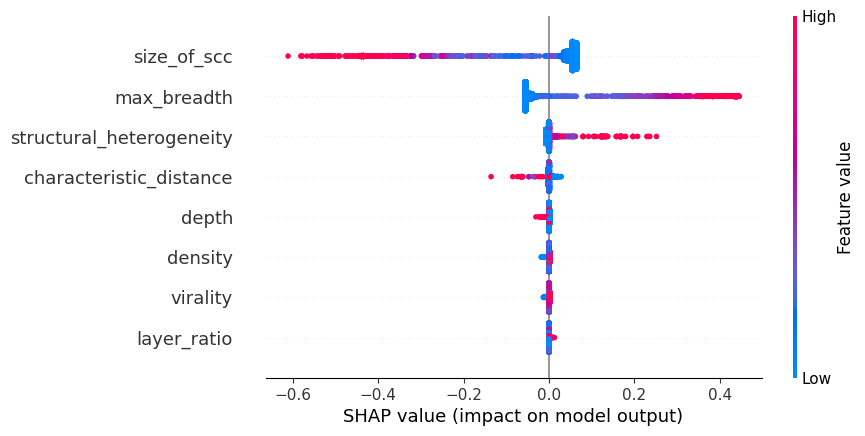

In [7]:
shap.plots.beeswarm(shap_values)

(0.7286916871273238, 0.16542155816435433, 0.16847826086956522, 0.5024741785318132, 0.16602399314481578, 0.15921309172930756, 0.4913529903805939)
(0.27130831287267626, 0.16054564533053514, 0.8315217391304348, 0.49752582146818686, 0.19144144144144146, 0.16372764310606172, 0.5086470096194061)


In [2]:
import smote_variants as sv
import pandas as pd

def oversample_data(X: pd.Series, y: pd.Series):
    
    oversampler = sv.polynom_fit_SMOTE_poly()
    X_samp, y_samp = oversampler.sample(X, y)
    X_samp, y_samp = pd.DataFrame(X_samp), pd.Series(y_samp)

    return X_samp, y_samp


In [18]:
from copy import copy 
import numpy as np
from sklearn.preprocessing import StandardScaler

normalized_df = copy(X_train_val)
cd_first_quantile = np.quantile(normalized_df["characteristic_distance"], 0.25)
cd_third_quantile = np.quantile(normalized_df["characteristic_distance"], 0.75)
normalized_df["depth"] = np.log(normalized_df["depth"])
normalized_df["max_breadth"] = np.log(normalized_df["max_breadth"])
normalized_df["size"] = np.log(normalized_df["size"])
normalized_df["strongly_cc"] = np.log(normalized_df["strongly_cc"])
normalized_df["characteristic_distance"] = np.log(normalized_df["characteristic_distance"] + cd_first_quantile**2 / cd_third_quantile)

scaler = StandardScaler().set_output(transform="pandas")
scaled_X_train = scaler.fit_transform(normalized_df)
# scaled_resampled_X_train, scaled_resampled_y_train = oversample_data(scaled_X_train.to_numpy(), y_train_val.to_numpy())
scaled_resampled_X_train, scaled_resampled_y_train = pd.DataFrame(scaled_X_train.to_numpy()), pd.Series(y_train_val.to_numpy())

In [12]:
# with feature selection, with oversample

from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(scaled_resampled_X_train, scaled_resampled_y_train)
test_model(dummy_clf)

(0.49210803226937916, 0.15235749472202675, 0.4706521739130435, 0.4834440292400851, 0.17618815104166666, 0.16703239334870695, 0.519712281563108)
(0.5078919677306208, 0.17027972027972027, 0.5293478260869565, 0.5165559707599149, 0.1970064724919094, 0.15636695640124387, 0.480287718436892)


In [14]:
# with feature selection, without oversample

from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(scaled_resampled_X_train, scaled_resampled_y_train)
test_model(dummy_clf)

(0.7346545071904594, 0.18288770053475936, 0.1858695652173913, 0.5130518884221629, 0.1834763948497854, 0.1610411497361327, 0.4988571272707435)
(0.2653454928095405, 0.15712187958883994, 0.8141304347826087, 0.4869481115778372, 0.18736241745047028, 0.16165690123738294, 0.5011428727292564)


In [17]:
# without feature selection, with oversample

from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(scaled_resampled_X_train, scaled_resampled_y_train)
test_model(dummy_clf)

(0.4936864258155033, 0.15957078573901004, 0.5010869565217392, 0.4966748040659721, 0.18475472907983329, 0.16697785437507373, 0.5195249849980906)
(0.5063135741844966, 0.16317099182367578, 0.4989130434782609, 0.503325195934028, 0.18854748603351956, 0.15640813369961226, 0.48047501500190937)


In [19]:
# without feature selection, without oversample

from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(scaled_resampled_X_train, scaled_resampled_y_train)
test_model(dummy_clf)

(0.7423710978603999, 0.18556701030927836, 0.17608695652173914, 0.5137021984616225, 0.18359020852221214, 0.16280307862244833, 0.5051088320331678)
(0.25762890213960016, 0.15696831642161937, 0.8239130434782609, 0.48629780153837765, 0.18728997825657245, 0.15997842303660448, 0.49489116796683214)


In [2]:
import os 

os.path.join('one', 'two')

'one\\two'

In [11]:
import pandas as pd 

true_df =  pd.read_csv('../rq2_vosoughi_True_features.csv')
false_df =  pd.read_csv('../rq2_vosoughi_False_features.csv')
vosoughi_df = pd.concat([false_df, true_df])

In [12]:
filtered_df = vosoughi_df[(vosoughi_df.characteristic_distance != -99999) & (vosoughi_df.depth != 0)]
filtered_df.shape

(38007, 17)

In [13]:
filtered_df[(filtered_df.characteristic_distance != -99999) & (filtered_df.depth != 0)].groupby(['veracity']).count()

,Unnamed: 0,cascade_root_id,cascade_id,time_bucket,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,avg_cluster_coef,density,layer_ratio,structural_heterogeneity,characteristic_distance
veracity,,,,,,,,,,,,,,,,
0.0,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858
1.0,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149
